---

### 🎓 **Professor**: Apostolos Filippas

### 📘 **Class**: AI Engineering

### 📋 **Homework 6**: Multimodal Image Search

### 📅 **Due Date**: Day of Lecture 8, 11:59 PM

### Difficulty: ★★★★☆

**Note**: You are not allowed to share the contents of this notebook with anyone outside this class without written permission by the professor.

---

### Instructions

1. Use any external resource or collaborate with your classmates. But you have to cite external resources you've used and mention classmates you've collaborated with.
2. Run all cells before submitting to ensure they work.
3. Some tasks involve LLM API calls that cost money. Budget wisely.
4. I suggest you save intermediate results (descriptions, metadata) to a `temp/` folder so that you don't re-run expensive API calls.

## 1. Setup & Explore

The `data/dogs/` directory contains dog images
- These include different breeds, artistic styles (photographs, sketches, paintings, cartoons), settings, and some images with text or unusual content.

### Load and display images

Load all `.png` file paths from `data/dogs/`, sorted by name. 
- Explore the data
- How many images are there? Are they AI generated? What type of variety do you observe? What breeds do you see? What artistic styles? Any images that look unusual or have text?

Found 100 images in ../data/dogs/


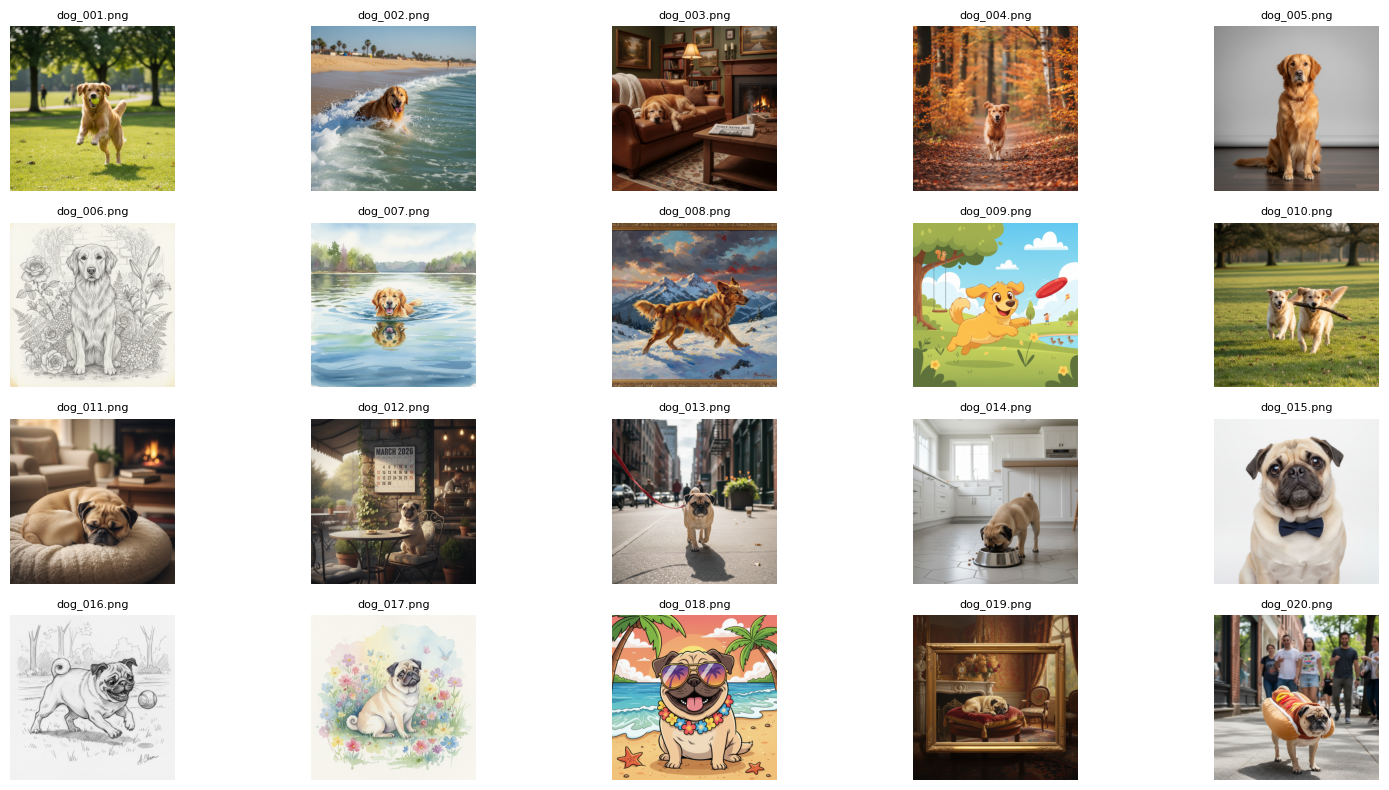

In [4]:
import os
from glob import glob
from PIL import Image
import matplotlib.pyplot as plt

def load_dog_images(image_dir='../data/dogs/'):
    image_paths = sorted(glob(os.path.join(image_dir, '*.png')))
    print(f"Found {len(image_paths)} images in {image_dir}")
    return image_paths

def show_images(image_paths, ncols=5, figsize=(16, 8)):
    n_images = len(image_paths)
    nrows = (n_images + ncols - 1) // ncols
    plt.figure(figsize=figsize)
    for i, img_path in enumerate(image_paths):
        img = Image.open(img_path)
        plt.subplot(nrows, ncols, i+1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(os.path.basename(img_path), fontsize=8)
    plt.tight_layout()
    plt.show()

# Example usage:
image_paths = load_dog_images()
show_images(image_paths[:20])  # Show the first 15 images


## 2. The Task

Your goal is to build a **searchable index** over these dog images that allows us to find relevant images using natural language queries, metadata filters, or both.

There are broadly two approaches:

**Approach A: Text-based pipeline**
1. Use a vision LLM to generate text descriptions of each image
2. Extract structured metadata (breed, style, setting, etc.) using an LLM with structured output
3. Embed the descriptions and build a searchable index (e.g., using LanceDB)
4. Search using semantic similarity over text + metadata filters

**Approach B: Multimodal embeddings**
1. Use a multimodal embedding model to embed the images directly
2. Embed text queries in the same space
3. Search by comparing query embeddings to image embeddings

You may combine both approaches or use a different method entirely. Use any tools from the course — `litellm`, `lancedb`, `pydantic`, `sentence-transformers` - or any other tools you want.


In [29]:
import litellm
import os
import pandas as pd
import base64
import re
import json
from pydantic import BaseModel, Field
from typing import List, Optional

# Add tqdm for progress bar
from tqdm import tqdm

# 1. Define the Schema
class DogImageMetadata(BaseModel):
    filename: str
    breed: str = Field(description="The breed of the dog.")
    style: str = Field(description="Artistic style: photo, cartoon, etc.")
    setting: str = Field(description="Location: beach, park, etc.")
    activity: str = Field(description="What the dog is doing.")
    mood: str = Field(description="Emotion: happy, sad, etc.")
    color: str = Field(description="Main colors.")
    description: str = Field(description="One-sentence description.")

# 2. Helper to encode local images
def encode_image(image_path: str):
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode('utf-8')

def extract_metadata_with_image(image_path: str, model: str) -> DogImageMetadata:
    base64_image = encode_image(image_path)
    
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "text", "text": "Analyze this dog image and return metadata in the requested schema."},
                {
                    "type": "image_url",
                    "image_url": {"url": f"data:image/jpeg;base64,{base64_image}"}
                }
            ]
        }
    ]

    response = litellm.completion(
        model=model,
        messages=messages,
        response_format=DogImageMetadata,
        # NEW in 2026: Ensures the model adheres to the schema without truncating strings
        enforce_validation=True, 
        max_tokens=1000 # Increased to prevent truncation
    )
    
    # LiteLLM's .parsed attribute directly returns the Pydantic object
    if hasattr(response.choices[0].message, 'parsed') and response.choices[0].message.parsed:
        data = response.choices[0].message.parsed
        data.filename = os.path.basename(image_path)
        return data
        
    # Fallback if parsing fails
    return DogImageMetadata.model_validate_json(response.choices[0].message.content)

# 3. Processing Loop
dogs_root = "../data/dogs"
dog_image_files = []
for root, _, files in os.walk(dogs_root):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png', '.webp')):
            dog_image_files.append(os.path.join(root, file))

metadata_list = []

# Add progress bar using tqdm
for filepath in tqdm(dog_image_files, desc="Extracting metadata"):
    metadata = None
    # Primary attempt: Gemini
    try:
        # Note: Use 'gemini/gemini-1.5-flash' for faster/cheaper vision tasks
        metadata = extract_metadata_with_image(filepath, model="gemini/gemini-2.5-flash")
    except Exception:
        print(f"Gemini failed for {filepath}, trying Ollama...")
        # Fallback attempt: Ollama
        try:
            # Note: Ollama might struggle with response_format; 
            # ensure your Ollama version is up to date!
            metadata = extract_metadata_with_image(filepath, model="ollama/llava")
        except Exception as e:
            print(f"Critical failure for {filepath}: {e}")

    if metadata:
        metadata.filename = os.path.relpath(filepath, dogs_root)
        metadata_list.append(metadata)

# 4. Display Results
df_metadata = pd.DataFrame([m.model_dump() for m in metadata_list])
print(df_metadata)
df_metadata['breed'] = df_metadata['breed'].apply(lambda x: x.lower())

KeyboardInterrupt: 

In [31]:
df_metadata['breed'] = df_metadata['breed'].apply(lambda x: x.lower())
display(df_metadata)

,filename,breed,style,setting,activity,mood,color,description,embedding
0,dog_001.png,golden retriever,photo,park,running and playing fetch with a tennis ball,joyful and energetic,"golden, green, yellow",A happy Golden Retriever runs across a sunny g...,"[-0.02550843544304371, -0.011442729271948338, ..."
1,dog_002.png,golden retriever,photo,"beach, ocean","playing in the waves, splashing","happy, joyful","golden, brown, blue, white",A happy Golden Retriever splashes and plays in...,"[-0.018573353067040443, -0.01482208538800478, ..."
2,dog_003.png,golden retriever,photo,Cozy living room with a fireplace,Sleeping,Peaceful and content,"Golden, brown, green, warm orange",A Golden Retriever peacefully sleeps on a brow...,"[-0.010750207118690014, -0.008294341154396534,..."
3,dog_004.png,golden retriever,photo,autumn forest path,running,happy,"golden, orange, brown, yellow",A happy Golden Retriever runs towards the came...,"[-0.023044560104608536, -0.006915985606610775,..."
4,dog_005.png,golden retriever,photo,studio,sitting,calm,"golden, brown, grey",A calm Golden Retriever sits on a dark wooden ...,"[-0.018097177147865295, -0.009107176214456558,..."
...,...,...,...,...,...,...,...,...,...
95,dog_096.png,poodle,pencil drawing,beach with cliffs and ocean waves,standing and observing,calm and alert,shades of grey and black,A detailed pencil drawing of a Poodle standing...,"[-0.014984984882175922, -0.00425016600638628, ..."
96,dog_097.png,poodle,watercolor painting,garden with wisteria and roses,leaping or jumping with a bee nearby,happy and playful,"white, lavender, purple, green",A happy white Poodle is playfully leaping thro...,"[-0.007355536799877882, -0.008178719319403172,..."
97,dog_098.png,poodle,"Oil painting, classical portrait","Indoor, formal studio with column and bust","Sitting regally, posing for a portrait","Dignified, regal, calm","Cream, gold, blue, red, dark brown","A majestic cream-colored Poodle, adorned with ...","[-0.014715502969920635, -0.00600097980350256, ..."
98,dog_099.png,poodle,Cartoon illustration with textured brushes,Park,Running and celebrating,Joyful and playful,"Blue, yellow, pink, green, orange, light brown","A vibrant, happy poodle with multicolored fur ...","[-0.02155241370201111, -0.0008093825308606029,..."


In [10]:
# Create text embeddings from the metadata, not from images.
# We'll use OpenAI's 'text-embedding-ada-002' to embed a serialized version of the image's metadata.
# This ensures that the text (descriptions, or structured fields) powers the search.

import pandas as pd
import numpy as np
import os
from dotenv import load_dotenv
load_dotenv()

import openai

# Load metadata (without embeddings yet)
df_metadata = pd.read_csv('metadata.csv')

openai.api_key = os.environ.get("OPENAI_API_KEY")

def serialize_metadata(row):
    """
    Serializes a DataFrame row into a string representation combining useful fields for semantic search.
    Adjust fields as needed to best represent the image.
    """
    # Example: create a descriptive string from metadata fields. Adjust as needed.
    fields = []
    for col in df_metadata.columns:
        if col != "embedding" and col != "filename":
            val = row[col]
            if pd.notna(val):
                fields.append(f"{col}: {val}")
    return ". ".join(fields)

def extract_text_embedding_openai(text, model="text-embedding-ada-002"):
    """
    Extracts a text embedding using OpenAI's text embedding model.
    Returns a 1536-dim embedding if successful; else, a zero-vector.
    """
    try:
        response = openai.embeddings.create(
            model=model,
            input=text
        )
        embedding = np.array(response.data[0].embedding)
        return embedding
    except Exception as e:
        print(f"Text embedding extraction failed for: {text[:50]}... Error: {e}")
        # OpenAI ada-002 is 1536 dimensions
        return np.zeros(1536)

embeddings = []
for i, row in df_metadata.iterrows():
    text = serialize_metadata(row)
    emb = extract_text_embedding_openai(text)
    embeddings.append(emb)

df_metadata['embedding'] = embeddings
df_metadata['embedding'] = df_metadata['embedding'].apply(lambda x: x.tolist() if isinstance(x, np.ndarray) else x)

print("Created text metadata embeddings for each photo and stored in df_metadata:")
print(df_metadata.head())

Created text metadata embeddings for each photo and stored in df_metadata:
      filename             breed  style                            setting  \
0  dog_001.png  Golden Retriever  photo                               park   
1  dog_002.png  Golden Retriever  photo                       beach, ocean   
2  dog_003.png  Golden Retriever  photo  Cozy living room with a fireplace   
3  dog_004.png  Golden Retriever  photo                 autumn forest path   
4  dog_005.png  Golden Retriever  photo                             studio   

                                       activity                  mood  \
0  running and playing fetch with a tennis ball  joyful and energetic   
1               playing in the waves, splashing         happy, joyful   
2                                      Sleeping  Peaceful and content   
3                                       running                 happy   
4                                       sitting                  calm   

                 

In [ ]:
df_metadata.to_csv('data/embeddings.csv', index=False)

## 3. Your Own Queries

To make a good search system, you will need to come up with some of your own queries and "golden" answers to these queries to evaluate your system with. Show us your work.

In [32]:
import numpy as np

# Assume the CSV is already loaded as df_metadata, and it contains a column "embedding" as serialized Python lists or NumPy arrays.
# If not, you need to parse the embeddings column. Let's ensure it's loaded as a list of vectors.
import ast

if isinstance(df_metadata['embedding'].iloc[0], str):
    # If embeddings are in string format, parse them
    df_metadata['embedding'] = df_metadata['embedding'].apply(lambda x: np.array(ast.literal_eval(x)))

# Create a matrix of embeddings for efficient search
emb_matrix = np.vstack(df_metadata['embedding'].values)

def compute_query_embedding(query):
    """
    Given a natural language query, returns its vector embedding using the same embedding model as the images.
    Uses the extract_metadata_with_image function logic, but for text. You may need a text-to-embedding function.
    """
    
    return extract_text_embedding_openai(query)


def filter_df_with_metadata(df, filter_str):
    """Applies metadata filtering based on queried condition string.

    Example: "breed = 'pug'" or "style = 'cartoon'"
    """
    if not filter_str:
        return df
    # Check the filter_str. The replace("=", "==", 1) replaces the first '=' with '==' (yields "breed == 'husky'" for input "breed = 'husky'").
    # This is correct for pandas query syntax, since query expects '==' for equality comparison.
    filter_str = filter_str.replace("=", "==", 1).lower()
    print(f"Filter string after replacement: {filter_str}")  # should print: breed == 'husky'
    try:
        return df.query(filter_str)
    except Exception as e:
        print(f"Filter parse error: {e}")
        return df

def cosine_similarity(a, b):
    a = np.array(a, dtype=np.float32)
    b = np.array(b, dtype=np.float32)
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-8)

def query_index(query, filter=None, k=5):
    """
    Semantic search using the metadata embeddings.
    Returns top k results as a list of dicts (must include at least the "filename" key).
    Supports an optional filter string (on columns of df_metadata).
    """
    # 1. Compute query embedding
    query_emb = compute_query_embedding(query)
    # 2. Filter metadata frame if needed
    filtered_df = filter_df_with_metadata(df_metadata, filter)
    filtered_indices = filtered_df.index.tolist()
    filtered_embeddings = emb_matrix[filtered_indices]
    # 3. Compute similarity with each embedding (cosine)
    sims = np.dot(filtered_embeddings, query_emb) / (np.linalg.norm(filtered_embeddings, axis=1) * np.linalg.norm(query_emb) + 1e-8)
    # 4. Get top-k
    topk_idx = np.argsort(-sims)[:k]
    results = []
    for i in topk_idx:
        row = filtered_df.iloc[i].to_dict()
        row['score'] = float(sims[i])
        results.append(row)
    return results


In [34]:
df_metadata['breed'].unique()

<StringArray>
[    'golden retriever',                  'pug',      'german shepherd',
       'siberian husky',                'husky',                'corgi',
 'pembroke welsh corgi',            'dalmatian',   'labrador retriever',
              'bulldog',      'english bulldog',            'shiba inu',
               'beagle',               'poodle',         'goldendoodle']
Length: 15, dtype: str

## 4. Evaluation Queries

We will evaluate your index by running queries against it — queries similar in spirit to the examples below, but not identical.

**Important:** Define a function called `query_index(query, filter=None, k=5)` that takes a natural language query, an optional metadata filter string (e.g., `"breed = 'pug'"`), and returns the top-k results as a list of dicts with at least a `"filename"` key. We will call this function to test your system.

### Example semantic queries
1. `"a happy dog at the beach"`
2. `"a dog sitting in a cafe"`
3. `"a pencil drawing of a dog"`

### Example filtered queries
4. Find all **corgi** images — `query_index("dog", filter="breed = 'corgi'", k=20)`
5. Find all **cartoon** images
6. Find all images set in a **living room**
7. Find all images where the dog is **eating**

### Example combined queries
8. `"dog in the snow"` among **huskies** only
9. `"cute dog posing"` among **pencil sketches** only
10. `"running on the beach"` among **dalmatians** only

Run these example queries and display results clearly — filenames, metadata, and scores.


--- Example Query 1 ---
Query: a happy dog at the beach
Filename: dog_084.png, Score: 0.8879, Metadata: breed:beagle, style:photo, setting:beach, activity:running, mood:happy, color:brown, black, white, blue, yellow, description:A happy tricolor Beagle dog is running along a sunny sandy beach with blue ocean waves and palm trees in the background., embedding:[-0.03112923726439476, -0.017367113381624222, -0.0007602223777212203, -0.030497705563902855, -0.014472595416009426, 0.03370799124240875, 0.0013831196120008826, -0.005499585997313261, -0.008308585733175278, -0.029050445184111595, -0.027497930452227592, 0.04018118605017662, 0.0037694531492888927, 0.006295579019933939, 0.008788811974227428, -0.007486278656870127, 0.015946168452501297, -0.00649951072409749, 0.005141060333698988, -0.0008749341359362006, -0.01869596168398857, 0.022603562101721764, 0.007986241020262241, -0.018367039039731026, -0.0014768625842407346, 0.0029553696513175964, 0.027892637997865677, -0.007558641955256462, 0.00

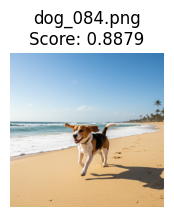

Filename: dog_002.png, Score: 0.8853, Metadata: breed:golden retriever, style:photo, setting:beach, ocean, activity:playing in the waves, splashing, mood:happy, joyful, color:golden, brown, blue, white, description:A happy Golden Retriever splashes and plays in the ocean waves at a sunny beach., embedding:[-0.018573353067040443, -0.01482208538800478, -0.013580376282334328, -0.029879441484808922, -0.002223639516159892, 0.02998400665819645, -0.0001625658624107018, 0.003761071478947997, -0.02156652696430683, -0.02573605440557003, -0.024507416412234306, 0.038819748908281326, 0.007881585508584976, 0.006133389193564653, 0.004960300866514444, -0.015462545678019524, 0.01620757207274437, -0.00025814477703534067, 0.014835155569016933, -0.015763171017169952, -0.02736988291144371, 0.014678308740258217, 0.005858906079083681, -0.02786656655371189, 0.0056497761979699135, -0.018311941996216774, 0.02091299556195736, -0.006718299817293882, 0.006437281146645546, -0.018011316657066345, 0.01152175292372703

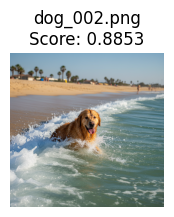

Filename: dog_057.png, Score: 0.8722, Metadata: breed:dalmatian, style:watercolor, setting:beach at sunset, activity:running along the shore, mood:happy and energetic, color:white, black, orange, red, blue, brown, description:A happy Dalmatian dog runs along the wet sand of a beach at sunset, with a vibrant orange and red sky above the blue ocean waves., embedding:[-0.012935049831867218, -0.011743663810193539, -0.0044775172136723995, -0.03710316866636276, -0.01641756296157837, 0.031787753105163574, -0.01708526350557804, -0.005528162699192762, -0.00158005952835083, -0.02360515668988228, -0.017150724306702614, 0.041397396475076675, 0.01751730404794216, 0.008581907488405704, 0.0036036157980561256, 0.013281991705298424, 0.025411874055862427, -0.013537288643419743, 0.01828974112868309, -0.01403479091823101, -0.02835760824382305, 0.00907286349684, 0.007377429399639368, 0.0012322991387918591, -0.002156932605430484, -0.001414771075360477, 0.029064584523439407, -0.01389077678322792, 0.014519200

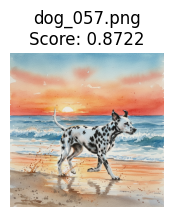

Filename: dog_034.png, Score: 0.8706, Metadata: breed:siberian husky, style:photo, setting:sandy beach by the ocean, activity:running and splashing in shallow water, mood:happy, color:gray, white, black, blue, brown, golden, description:A happy Siberian Husky runs through the shallow water on a sunny beach, splashing water around as it moves towards the viewer., embedding:[-0.005895534530282021, 0.00045870451140217483, 0.00034199151559732854, -0.03689190372824669, -0.022291572764515877, 0.03180785849690437, -0.004872207995504141, -0.012143041007220745, -0.007632582448422909, -0.0313124917447567, -0.016138577833771706, 0.030869266018271446, 0.013283692300319672, 0.0008652650285512209, 0.010722116567194462, -0.0148480124771595, 0.010246302001178265, -0.0072284662164747715, 0.02428608201444149, -0.017285745590925217, -0.03441505879163742, 0.008734125643968582, 0.007163286209106445, -0.01698591746389866, -0.02199174463748932, 0.0011887209257110953, 0.03032175451517105, -0.00521440291777253

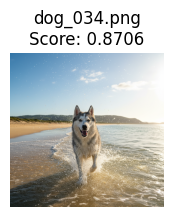

Filename: dog_042.png, Score: 0.8645, Metadata: breed:pembroke welsh corgi, style:photo, setting:beach, activity:running, mood:happy, color:orange, white, blue, tan, description:A happy Pembroke Welsh Corgi with orange and white fur joyfully runs towards the camera on a sandy beach at the edge of the ocean under a partly cloudy sky., embedding:[-0.017195794731378555, -0.015527060255408287, -0.005622203927487135, -0.037468321621418, -0.004145764280110598, 0.04941020905971527, 0.0032804335933178663, -0.009210636839270592, -0.008056862279772758, -0.027873093262314796, -0.019581565633416176, 0.02462688274681568, 3.5367938835406676e-05, 0.008715230971574783, -0.00042492453940212727, 0.00037338765105232596, 0.018603790551424026, -0.01194840483367443, -0.0025242881383746862, -0.0014291804982349277, -0.037051137536764145, 0.021941261366009712, -4.962715320289135e-05, -0.01624409481883049, 0.012456848286092281, -0.01158988755196333, 0.01995963789522648, -0.00345154432579875, 0.01456232275813818

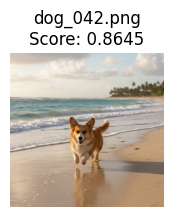


--- Example Query 2 ---
Query: a dog sitting in a cafe
Filename: dog_078.png, Score: 0.8884, Metadata: breed:shiba inu, style:Cartoon, setting:Cafe, activity:Drinking coffee, mood:Happy, color:Tan, white, brown, pink, green, light blue, description:A happy cartoon Shiba Inu dog sits at a cafe table, enjoying a cup of hot coffee with a speech bubble that says 'MUCH COFFEE. VERY CAFE.'., embedding:[-0.009017402306199074, -0.007071956992149353, -0.01278998889029026, -0.03228387609124184, 0.000451855972642079, -0.0019027244998142123, -0.020532336086034775, 0.0037167207337915897, -0.006828776095062494, -0.021334175020456314, 0.0026618423871695995, 0.031994689255952835, -5.4479452956002206e-05, -0.011212600395083427, 0.00045308831613510847, 0.00187972083222121, 0.02203085459768772, -0.010062421672046185, 0.028287827968597412, -0.0016406479990109801, -0.025251355022192, 0.036253638565540314, -0.006023650988936424, -0.001325170393101871, -0.006855065934360027, 0.012540236115455627, 0.03422932

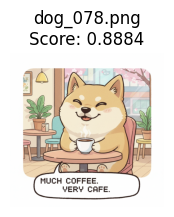

Filename: dog_063.png, Score: 0.8862, Metadata: breed:bulldog, style:photo, setting:outdoor cafe on a cobblestone street, activity:sitting at a table, looking out, mood:calm, playful, content, color:white, brown, tan, warm tones, description:A bulldog sits calmly on a chair at an outdoor cafe on a cobblestone street, with its tongue playfully sticking out, next to a chalkboard sign displaying 'Spring 2026 Specials'., embedding:[-0.014638449065387249, 0.0036130354274064302, -0.01773913949728012, -0.023913903161883354, 0.007252686191350222, 0.02608305588364601, -0.004305034875869751, -0.007831570692360401, -0.01550344843417406, -0.028584899380803108, -0.011777297593653202, 0.020733367651700974, 0.014931218698620796, 0.01969536766409874, -0.006959917489439249, -0.008929453790187836, 0.022915827110409737, 0.0022989020217210054, 0.01606237143278122, 0.005971821956336498, -0.024486133828759193, 0.026335900649428368, 0.002543430542573333, -0.002448613289743662, -0.018697291612625122, 0.002977

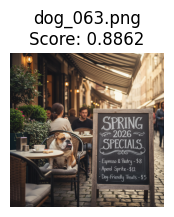

Filename: dog_095.png, Score: 0.8810, Metadata: breed:poodle, style:photo, setting:Outdoor European cafe, activity:Sitting attentively at a table, mood:Calm and observant, color:Cream, red, brown, white, description:A cream-colored Poodle wearing a pearl necklace sits attentively on a red cushioned chair at an outdoor European cafe with a coffee cup and macaron on the table., embedding:[-0.014057660475373268, -0.0072266398929059505, 0.0009816295932978392, -0.037425555288791656, 0.006540900561958551, 0.03460347279906273, 0.017631419003009796, -0.014928022399544716, -0.021033741533756256, -0.02375032566487789, -0.0023390972055494785, 0.02419869415462017, 0.00587494159117341, -0.0009445403120480478, 0.00012682472879532725, 0.015574200078845024, 0.01831715926527977, 0.0028896669391542673, 0.015903882682323456, -0.020598560571670532, -0.031438522040843964, 0.020031508058309555, -0.004958424251526594, -0.008176125586032867, 0.0032440756913274527, -0.0028072462882846594, 0.02690209075808525, 

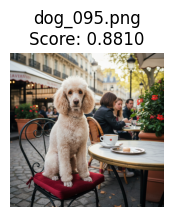

Filename: dog_044.png, Score: 0.8803, Metadata: breed:corgi, style:photo, setting:outdoor cafe on a cobblestone street, activity:sitting at a cafe table with a croissant and coffee, mood:calm and attentive, color:orange, white, brown, grey, description:A Corgi sits at an outdoor cafe table with a cobblestone street in the background, looking calmly at the camera with a croissant and coffee in front of it., embedding:[-0.0126742422580719, -0.004088889341801405, -0.007316614035516977, -0.034788429737091064, 0.009130976162850857, 0.0366290844976902, 0.009538550861179829, -0.010991355404257774, -0.018419723957777023, -0.03186967223882675, -0.00698792515322566, 0.0117341922596097, 0.0002134423266397789, -0.0013870670227333903, -0.00786881148815155, -0.006974777672439814, 0.029871243983507156, -0.004345266614109278, 0.012943767011165619, -0.007789926137775183, -0.03868010640144348, 0.03636613488197327, 0.00434197997674346, -0.011839373037219048, 0.012417864985764027, 0.01060350239276886, 0.0

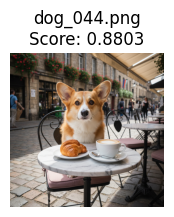

Filename: dog_012.png, Score: 0.8784, Metadata: breed:pug, style:photo, setting:outdoor cafe patio, activity:sitting at a table, mood:patient and expectant, color:fawn, black, green, brown, white, description:A fawn pug wearing a striped bandana sits upright on a chair at an outdoor cafe table, looking patiently at the viewer., embedding:[-0.004716317169368267, -0.0014973890502005816, -0.007099474314600229, -0.02853121981024742, 0.003433078993111849, 0.028771203011274338, 0.004572994541376829, -0.019345233216881752, -0.0329308956861496, -0.02991778403520584, -0.005382934585213661, 0.022025035694241524, 0.005606251303106546, 0.01626546122133732, -0.007692763581871986, -0.0005945392767898738, 0.01348566822707653, 0.01069920789450407, 0.009099326096475124, -0.03053107298910618, -0.020091844722628593, 0.02030516229569912, -0.008906006813049316, -0.012585734948515892, -0.013272350654006004, 0.01695874333381653, 0.017092067748308182, -0.010492555797100067, 0.0024481520522385836, -0.013265684

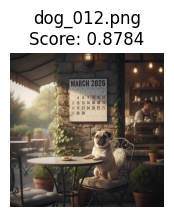


--- Example Query 3 ---
Query: a pencil drawing of a dog
Filename: dog_066.png, Score: 0.9125, Metadata: breed:bulldog, style:pencil drawing, setting:studio, activity:posing, mood:serious, color:grayscale, description:A detailed grayscale pencil drawing of a Bulldog posing with a serious expression against a white background., embedding:[-0.02713274024426937, 0.004919780883938074, -0.010095902718603611, -0.028605058789253235, 0.008459262549877167, 0.019508229568600655, -0.017575809732079506, -0.001264452701434493, -0.012153206393122673, -0.02991962991654873, 0.012034894898533821, 0.03588778153061867, 0.026869826018810272, 0.01555137149989605, -0.011640523560345173, 0.003687370801344514, 0.023859458044171333, 0.00464043440297246, 0.01572226546704769, -0.009767260402441025, -0.009504346176981926, 0.01791759952902794, 0.011068684980273247, -0.014355111867189407, -0.009405753575265408, -0.00232021720148623, 0.027211613953113556, -0.024569327011704445, -0.009570075199007988, -0.00572166917

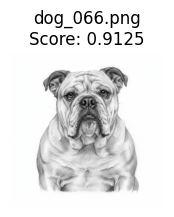

Filename: dog_096.png, Score: 0.9012, Metadata: breed:poodle, style:pencil drawing, setting:beach with cliffs and ocean waves, activity:standing and observing, mood:calm and alert, color:shades of grey and black, description:A detailed pencil drawing of a Poodle standing on a sandy beach, looking out towards the ocean with waves and cliffs in the background., embedding:[-0.014984984882175922, -0.00425016600638628, 0.011709505692124367, -0.030633021146059036, -0.005042513366788626, 0.03235695883631706, -0.0020670657977461815, -0.00854011531919241, -0.0071410746313631535, -0.024665549397468567, 0.0010567398276180029, 0.03174695000052452, 0.009269473142921925, 0.0038523345720022917, -0.010535902343690395, 0.01275049801915884, 0.013095284812152386, -0.01078123226761818, 0.008626312017440796, -0.010834276676177979, -0.023485315963625908, 0.01917547546327114, 0.024254458025097847, -0.013380398042500019, -0.0035937440115958452, -0.0018416281091049314, 0.02470533363521099, -0.01335387583822012

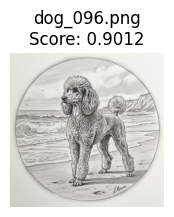

Filename: dog_086.png, Score: 0.8981, Metadata: breed:beagle, style:Pencil drawing, setting:Forest with bare trees and fallen leaves, activity:Sitting and looking directly forward, mood:Calm and serious, color:Black, white, and brown (represented by shades of gray), description:A detailed pencil drawing of a tricolor Beagle dog sitting calmly in a forest with bare trees and fallen leaves., embedding:[-0.025085261091589928, -0.006037808954715729, -0.013056344352662563, -0.02034841664135456, -0.011194964870810509, 0.02061528153717518, 0.0018780587706714869, -0.0035759839229285717, -0.014250563457608223, -0.026846567168831825, -0.00016366297495551407, 0.035519663244485855, -0.0012434216914698482, 0.0025268730241805315, -0.008045963943004608, 0.012549302540719509, 0.016959236934781075, -0.0009031694498844445, 0.017866576090455055, -0.005747593939304352, -0.021762797608971596, 0.034158654510974884, 0.01284952461719513, -0.030555982142686844, 0.0035326185170561075, 0.0015936812851577997, 0.0

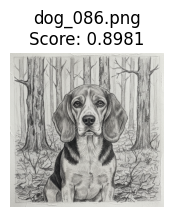

Filename: dog_016.png, Score: 0.8967, Metadata: breed:pug, style:pencil sketch, setting:park, activity:chasing a ball, mood:happy and playful, color:grayscale (black and white), description:A happy Pug in a pencil sketch is running through a park, playfully chasing a ball., embedding:[-0.01395371463149786, 0.0031192393507808447, 0.007921982556581497, -0.019506322219967842, -0.00366563955321908, 0.02696230448782444, 0.001523521146737039, -0.01275261864066124, -0.023549355566501617, -0.037673719227313995, 0.0022709243930876255, 0.028485005721449852, 0.02080586925148964, 0.014019348658621311, -0.013376139104366302, -0.010035385377705097, 0.013080786913633347, -0.007672574371099472, 0.0052835093811154366, -0.03139914199709892, -0.013783067464828491, 0.02028079889714718, -9.439965651836246e-05, -0.031976714730262756, -0.0036787663120776415, 0.00849299505352974, 0.022079160436987877, -0.014321262948215008, 0.012654168531298637, -0.00746910972520709, 0.007042491342872381, 0.013028280809521675

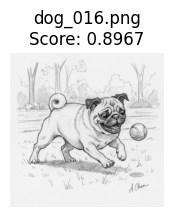

Filename: dog_026.png, Score: 0.8959, Metadata: breed:german shepherd, style:Pencil drawing, setting:Studio or plain background, activity:Posing for a portrait, mood:Alert and calm, color:Black, white, and grey, description:A detailed, monochromatic pencil drawing of a German Shepherd dog's head and chest, looking directly at the viewer with an alert and calm expression., embedding:[-0.013272969052195549, 0.0011677099391818047, -0.009899585507810116, -0.043231215327978134, -0.0018277904018759727, 0.02601398155093193, 0.0024635435547679663, -0.02100580371916294, -0.0073630595579743385, -0.03980593383312225, 0.018631460145115852, 0.03064589761197567, 0.007090594153851271, -0.0020142996218055487, -0.006947874091565609, 0.02597505785524845, 0.025456076487898827, -0.004145370330661535, 0.008219379931688309, -0.005326054524630308, -0.021096626296639442, 0.018696332350373268, 0.01925423927605152, -0.010431542061269283, 0.01227392815053463, -0.005825574975460768, 0.03521294146776199, -0.010301

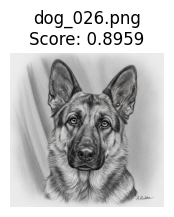


--- Example Query 4 ---
Query: dog
Filter: breed = 'corgi'
Filter string after replacement: breed == 'corgi'
Filename: dog_045.png, Score: 0.8181, Metadata: breed:corgi, style:photo, setting:autumn park, activity:sitting on a bench with a treat, mood:happy, color:orange, brown, white, description:A happy Corgi dog sits on a wooden park bench, holding a treat in its mouth, surrounded by vibrant autumn leaves., embedding:[-0.020789265632629395, -0.01919606886804104, -0.0006472358945757151, -0.025322750210762024, 0.0047860643826425076, 0.049013447016477585, -0.0016741511644795537, -0.006036011036485434, -0.01847071200609207, -0.02940288558602333, -0.00015432063082698733, 0.013231298886239529, -0.011793537065386772, 0.013160058297216892, 0.0014175234828144312, -0.008153796195983887, 0.024286525323987007, -0.006884420290589333, 0.005132552236318588, -0.008192654699087143, -0.03225250542163849, 0.043728698045015335, -0.0036267878022044897, -0.022511988878250122, 0.015374989248812199, -0.004

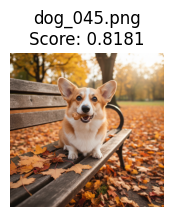

Filename: dog_046.png, Score: 0.8118, Metadata: breed:corgi, style:pencil sketch, setting:city street with buildings and cobblestones, activity:walking and exploring, mood:curious and alert, color:grayscale, description:A grayscale pencil sketch of a curious Corgi dog walking on a cobblestone street with city buildings in the background., embedding:[-0.006692185997962952, 0.006316220387816429, -0.004907167050987482, -0.03211726248264313, 0.002600700594484806, 0.03695577383041382, -0.002628489164635539, -0.011298581026494503, -0.01783711090683937, -0.04276198893785477, 0.0027886831667274237, 0.01108934823423624, 0.011854356154799461, 0.0032185916788876057, -0.01779787987470627, -0.0006971707916818559, 0.022257158532738686, 0.003143398556858301, 0.001236599637195468, -0.004498509224504232, -0.03279726952314377, 0.047391269356012344, 0.016594789922237396, -0.029711082577705383, 0.013757068663835526, -0.0001127896539401263, 0.027592599391937256, -0.018373271450400352, 0.00890547875314951, 

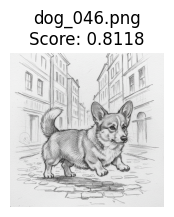

Filename: dog_044.png, Score: 0.8088, Metadata: breed:corgi, style:photo, setting:outdoor cafe on a cobblestone street, activity:sitting at a cafe table with a croissant and coffee, mood:calm and attentive, color:orange, white, brown, grey, description:A Corgi sits at an outdoor cafe table with a cobblestone street in the background, looking calmly at the camera with a croissant and coffee in front of it., embedding:[-0.0126742422580719, -0.004088889341801405, -0.007316614035516977, -0.034788429737091064, 0.009130976162850857, 0.0366290844976902, 0.009538550861179829, -0.010991355404257774, -0.018419723957777023, -0.03186967223882675, -0.00698792515322566, 0.0117341922596097, 0.0002134423266397789, -0.0013870670227333903, -0.00786881148815155, -0.006974777672439814, 0.029871243983507156, -0.004345266614109278, 0.012943767011165619, -0.007789926137775183, -0.03868010640144348, 0.03636613488197327, 0.00434197997674346, -0.011839373037219048, 0.012417864985764027, 0.01060350239276886, 0.0

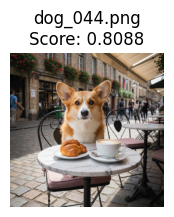

Filename: dog_047.png, Score: 0.8078, Metadata: breed:corgi, style:watercolor painting, setting:flower meadow, activity:running, mood:joyful, color:orange, white, green, pink, blue, yellow, description:A happy Corgi dog with fawn and white fur is joyfully running through a colorful meadow filled with pink, blue, and yellow wildflowers, rendered in a soft watercolor style., embedding:[-0.022718071937561035, -0.005941500421613455, -0.0159259382635355, -0.022110015153884888, 0.0008336536702699959, 0.03627646714448929, -0.009741861373186111, -0.00460894824936986, -0.0032472871243953705, -0.024775119498372078, -0.008001781068742275, 0.01249752752482891, 0.0017821267247200012, 0.011734221130609512, -0.010252888314425945, 0.009243771433830261, 0.03425823152065277, -0.009386083111166954, 0.0030354373157024384, -0.016624558717012405, -0.026651041582226753, 0.041477300226688385, 0.002262427704408765, -0.015938876196742058, -0.008519276976585388, 0.004576604813337326, 0.027401411905884743, -0.019

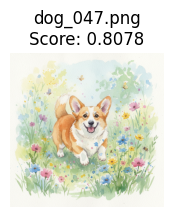

Filename: dog_041.png, Score: 0.8078, Metadata: breed:corgi, style:photo, setting:flower garden path, activity:walking, mood:happy, color:brown, white, red, purple, yellow, green, description:A happy Corgi walks through a vibrant and colorful flower garden path., embedding:[-0.015018307603895664, -0.007947832345962524, -0.021740419790148735, -0.020721135661005974, 0.014515116810798645, 0.05091257765889168, 0.0025546604301780462, -0.008205879479646683, -0.012495902366936207, -0.026707815006375313, -0.02304355427622795, 0.0023466104175895452, 0.00269336043857038, 0.01279910746961832, 0.001391838421113789, 0.01563761942088604, 0.024075739085674286, -0.008367158472537994, 0.007947832345962524, -0.003325574565678835, -0.026759423315525055, 0.04131324589252472, -0.0010104133980348706, -0.026372354477643967, 0.0017756825545802712, 0.0018063256284222007, 0.026527181267738342, -0.014308678917586803, 0.019482512027025223, -0.022050075232982635, -0.0001890997082227841, -0.0025030511897057295, -0.

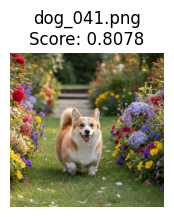


--- Example Query 5 ---
Query: dog
Filter: style = 'cartoon'
Filter string after replacement: style == 'cartoon'
Filename: dog_029.png, Score: 0.8213, Metadata: breed:german shepherd, style:cartoon, setting:park, activity:playing fetch with a frisbee, mood:happy, color:brown, black, blue, green, yellow, red, white, description:A happy cartoon German Shepherd dog is running in a sunny park to catch a red frisbee., embedding:[-0.007783547043800354, -0.011266001500189304, -0.011486903764307499, -0.03352512791752815, -0.016619626432657242, 0.02796359360218048, 0.00868664588779211, -0.016060873866081238, 0.00180944730527699, -0.037891190499067307, -0.006630308460444212, 0.03635786846280098, 0.022077206522226334, 0.0027872633654624224, 0.003794316668063402, 0.011694811284542084, 0.02084275335073471, -0.0017054934287443757, 0.009745676070451736, -0.003505195025354624, -0.022544998675584793, 0.016164828091859818, -0.0003975423751398921, -0.019179491326212883, 0.0174772460013628, 0.00186954555

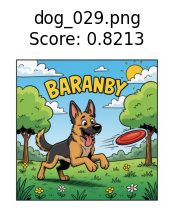

Filename: dog_088.png, Score: 0.8145, Metadata: breed:beagle, style:cartoon, setting:cozy living room, activity:sleeping, mood:peaceful, color:brown, white, yellow, green, orange, description:A cartoon beagle peacefully sleeps in a dog bed, covered by a blanket, beside a warm fireplace and a cozy armchair in a sunlit living room., embedding:[-0.01743527501821518, -0.01702612079679966, -0.017791636288166046, -0.020444544032216072, -0.012974168173968792, 0.0157590601593256, 0.01113297138363123, -0.004434710368514061, -0.0210252795368433, -0.02062932215631008, -0.01176650170236826, 0.030594222247600555, 0.008354677818715572, 0.009648134931921959, -0.012914774939417839, -0.005579683929681778, 0.018398769199848175, 0.012353836558759212, 0.008592251688241959, -0.015706267207860947, -0.02041814662516117, 0.01723729819059372, -0.006259409245103598, -0.010882198810577393, 0.0007048847037367523, -0.006949033122509718, 0.030567826703190804, -0.024470098316669464, -0.0026512574404478073, 0.0044347

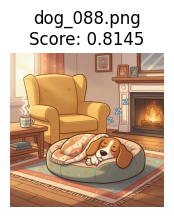

Filename: dog_059.png, Score: 0.8111, Metadata: breed:dalmatian, style:cartoon, setting:city street, activity:running alongside a fire truck, mood:happy, color:white, black, red, blue, grey, orange, green, description:A happy cartoon Dalmatian dog runs on a city street next to a red fire truck., embedding:[-0.0168161541223526, -0.013463319279253483, -0.01298898458480835, -0.04982467740774155, -0.022300247102975845, 0.018583539873361588, -0.00265432707965374, -0.016023429110646248, -0.007719316054135561, -0.0284860972315073, -0.012553635984659195, 0.03092924691736698, 0.027446458116173744, 0.010695281438529491, 2.0990748453186825e-05, 0.016777167096734047, 0.02295002155005932, -0.002157249953597784, 0.01310594379901886, -0.012644603848457336, -0.02929181605577469, 0.007816782221198082, -0.009363244287669659, -0.006556220818310976, 0.005614048335701227, 0.005675776861608028, 0.036205410957336426, -0.011273580603301525, 0.007537379395216703, -0.009031860157847404, 0.004119567573070526, -0

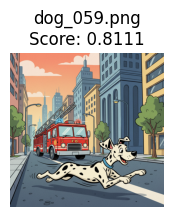

Filename: dog_018.png, Score: 0.8070, Metadata: breed:pug, style:cartoon, setting:tropical beach, activity:sitting, mood:happy, color:beige, brown, blue, orange, green, yellow, red, description:A cheerful cartoon pug wearing sunglasses and a colorful lei is happily sitting on a tropical beach at sunset., embedding:[-0.009192434139549732, -0.006347471848130226, 0.0055511463433504105, -0.02672480419278145, 0.0013737435219809413, 0.02541632018983364, 0.004107187502086163, -0.0072627500630915165, -0.0053528910502791405, -0.029976190999150276, -0.004725082777440548, 0.0381443053483963, 0.011221245862543583, 0.018067659810185432, 0.0009053655667230487, -0.011439327150583267, 0.020856449380517006, -0.009423731826245785, 0.00988632719963789, -0.024874422699213028, -0.015067397616803646, 0.0029540029354393482, -0.010692565701901913, -0.01287998165935278, 0.000479529844596982, 0.014882359653711319, 0.01490879338234663, -0.012774244882166386, 0.001139967585913837, -0.009873110800981522, 0.0119085

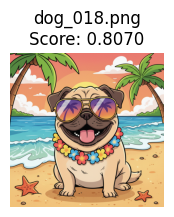


--- Example Query 6 ---
Query: dog
Filter: setting = 'living room'
Filter string after replacement: setting == 'living room'
Filename: dog_056.png, Score: 0.8138, Metadata: breed:dalmatian, style:pencil drawing, setting:living room, activity:sleeping, mood:peaceful, color:monochromatic, black, white, grey, description:A Dalmatian dog is peacefully sleeping curled up on a couch in a cozy living room, depicted in a detailed pencil drawing., embedding:[-0.02254689298570156, 0.015553180128335953, -0.009081386961042881, -0.0408923402428627, -0.012265091761946678, 0.02510429546236992, -0.015370508655905724, -0.012395571917295456, -0.022246789187192917, -0.023251483216881752, 0.011521358042955399, 0.03136732056736946, 0.02604374848306179, -0.002115402137860656, -0.019063085317611694, 0.021268190816044807, 0.024190936237573624, 0.002340479753911495, 0.015161741524934769, -0.016075098887085915, -0.01941538043320179, 0.009257534518837929, 0.006491365376859903, 0.0009223283850587904, 0.002555771

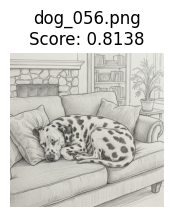


--- Example Query 7 ---
Query: dog
Filter: activity = 'eating'
Filter string after replacement: activity == 'eating'
Filename: dog_014.png, Score: 0.8116, Metadata: breed:pug, style:photo, setting:kitchen, activity:eating, mood:content, color:fawn, black, white, grey, description:A fawn Pug dog is contentedly eating kibble from a silver bowl on a light grey hexagonal tiled floor in a modern white kitchen., embedding:[-0.00642089219763875, -0.007341908290982246, -0.0013626778963953257, -0.016729062423110008, -0.006063629873096943, 0.017804129049181938, 0.0021747127175331116, -0.026011332869529724, -0.026299765333533287, -0.03657843545079231, 0.006922370754182339, 0.02142263948917389, -0.004087214358150959, 0.002315651159733534, -0.014185615815222263, -0.0006866651237942278, 0.014342942275106907, 0.009249493479728699, -0.008174428716301918, -0.042215973138809204, -0.021711071953177452, 0.029760951176285744, -0.004398589953780174, -0.018262997269630432, -0.011438955552875996, 0.014985359

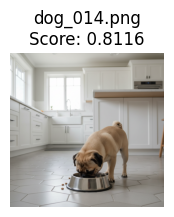


--- Example Query 8 ---
Query: dog in the snow
Filter: breed = 'husky'
Filter string after replacement: breed == 'husky'
Filename: dog_032.png, Score: 0.8385, Metadata: breed:husky, style:photo, setting:forest, activity:running with a toy, mood:happy, color:grey, white, blue, red, green, brown, description:A happy Husky with striking blue eyes is captured mid-stride, running through a sunlit forest with a red and blue rope toy in its mouth., embedding:[-0.017871486023068428, 0.0026622286532074213, -0.020376350730657578, -0.028241362422704697, -0.016664480790495872, 0.033951930701732635, 0.007540547288954258, -0.003913037944585085, -0.0016198874218389392, -0.03312130272388458, -0.016690436750650406, 0.018805943429470062, 0.008916275575757027, -0.01752106472849846, 0.0028552846051752567, 0.0007235551020130515, 0.017689786851406097, -0.00844904687255621, 0.014613866806030273, -0.021622292697429657, -0.04184290021657944, 0.028604760766029358, -0.0055418480187654495, -0.022751428186893463,

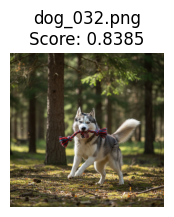

Filename: dog_037.png, Score: 0.8330, Metadata: breed:husky, style:watercolor painting, setting:forest, activity:sitting, mood:alert, color:blue, green, grey, white, description:A watercolor painting of a grey and white Husky sitting attentively in a cool-toned forest., embedding:[-0.004826688673347235, 0.0025900097098201513, -0.006567408796399832, -0.020408887416124344, -0.01204565167427063, 0.015040856786072254, -0.014275847934186459, -0.0052351257763803005, 0.01077495887875557, -0.024934109300374985, -0.004930418916046619, 0.016363415867090225, 0.009601512923836708, -0.013744231313467026, -0.011682596988976002, 0.0041524432599544525, 0.026503026485443115, -0.009646894410252571, 0.024661818519234657, -0.02154991775751114, -0.03721315413713455, 0.03755027800798416, 0.00722868787124753, -0.014172118157148361, -0.016026291996240616, 0.00523836724460125, 0.030470700934529305, -0.017608175054192543, 0.00741669861599803, -0.007831618189811707, -0.006346982438117266, -0.0015835040248930454,

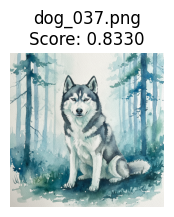

Filename: dog_039.png, Score: 0.8310, Metadata: breed:husky, style:Cartoon illustration, setting:Cozy living room with a fireplace and a snowy window view, activity:Sleeping and dreaming of food, mood:Peaceful and content, color:Blue, white, beige, brown, orange, green, description:A cute cartoon husky sleeps peacefully on a beige couch in a cozy living room, dreaming of bones and chicken while snow falls outside the window., embedding:[-0.0062024276703596115, -0.013634164817631245, -0.015159298665821552, -0.02135186456143856, -0.016013897955417633, 0.0018899819115176797, -0.0014947291929274797, -0.0115239592269063, -0.009893644601106644, -0.030555255711078644, -0.0010485290549695492, 0.022101283073425293, 0.021075762808322906, -0.005153898615390062, -0.014830606058239937, -0.006245157681405544, 0.027136852964758873, 0.003954170737415552, 0.020181719213724136, -0.032579999417066574, -0.038917191326618195, 0.0172103401273489, -0.006399643141776323, -0.004167820792645216, -0.000223100039

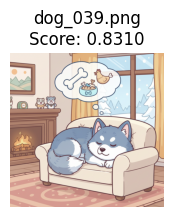


--- Example Query 9 ---
Query: cute dog posing
Filter: style = 'pencil sketch'
Filter string after replacement: style == 'pencil sketch'
Filename: dog_016.png, Score: 0.8484, Metadata: breed:pug, style:pencil sketch, setting:park, activity:chasing a ball, mood:happy and playful, color:grayscale (black and white), description:A happy Pug in a pencil sketch is running through a park, playfully chasing a ball., embedding:[-0.01395371463149786, 0.0031192393507808447, 0.007921982556581497, -0.019506322219967842, -0.00366563955321908, 0.02696230448782444, 0.001523521146737039, -0.01275261864066124, -0.023549355566501617, -0.037673719227313995, 0.0022709243930876255, 0.028485005721449852, 0.02080586925148964, 0.014019348658621311, -0.013376139104366302, -0.010035385377705097, 0.013080786913633347, -0.007672574371099472, 0.0052835093811154366, -0.03139914199709892, -0.013783067464828491, 0.02028079889714718, -9.439965651836246e-05, -0.031976714730262756, -0.0036787663120776415, 0.008492995053

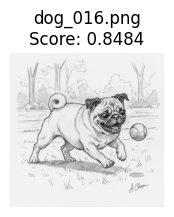

Filename: dog_046.png, Score: 0.8429, Metadata: breed:corgi, style:pencil sketch, setting:city street with buildings and cobblestones, activity:walking and exploring, mood:curious and alert, color:grayscale, description:A grayscale pencil sketch of a curious Corgi dog walking on a cobblestone street with city buildings in the background., embedding:[-0.006692185997962952, 0.006316220387816429, -0.004907167050987482, -0.03211726248264313, 0.002600700594484806, 0.03695577383041382, -0.002628489164635539, -0.011298581026494503, -0.01783711090683937, -0.04276198893785477, 0.0027886831667274237, 0.01108934823423624, 0.011854356154799461, 0.0032185916788876057, -0.01779787987470627, -0.0006971707916818559, 0.022257158532738686, 0.003143398556858301, 0.001236599637195468, -0.004498509224504232, -0.03279726952314377, 0.047391269356012344, 0.016594789922237396, -0.029711082577705383, 0.013757068663835526, -0.0001127896539401263, 0.027592599391937256, -0.018373271450400352, 0.00890547875314951, 

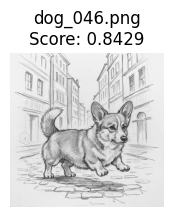

Filename: dog_076.png, Score: 0.8419, Metadata: breed:shiba inu, style:pencil sketch, setting:garden, activity:sitting, mood:happy, color:shades of grey, description:A happy Shiba Inu dog sits in a whimsical garden filled with various flowers and a picket fence, drawn in a detailed pencil sketch style., embedding:[-0.0010170415043830872, 0.0029511554166674614, -0.02163960412144661, -0.011467535980045795, -0.006764854770153761, 0.006626054644584656, -0.025354159995913506, -0.010773534886538982, -0.01266386080533266, -0.01833483763039112, 0.016656016930937767, 0.022181585431098938, 0.012399479746818542, -0.0028751457575708628, 0.00493401475250721, 0.019233735278248787, 0.01391967199742794, -0.010819802060723305, 0.03685474395751953, 0.0029263696633279324, -0.018348056823015213, 0.033629290759563446, 0.005766815505921841, -0.011004868894815445, -0.007653836626559496, -0.003479917999356985, 0.03809733688831329, -0.015492740087211132, -0.0030684745870530605, -0.020568858832120895, 0.0126704

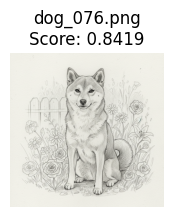


--- Example Query 10 ---
Query: running on the beach
Filter: breed = 'dalmatian'
Filter string after replacement: breed == 'dalmatian'
Filename: dog_057.png, Score: 0.8264, Metadata: breed:dalmatian, style:watercolor, setting:beach at sunset, activity:running along the shore, mood:happy and energetic, color:white, black, orange, red, blue, brown, description:A happy Dalmatian dog runs along the wet sand of a beach at sunset, with a vibrant orange and red sky above the blue ocean waves., embedding:[-0.012935049831867218, -0.011743663810193539, -0.0044775172136723995, -0.03710316866636276, -0.01641756296157837, 0.031787753105163574, -0.01708526350557804, -0.005528162699192762, -0.00158005952835083, -0.02360515668988228, -0.017150724306702614, 0.041397396475076675, 0.01751730404794216, 0.008581907488405704, 0.0036036157980561256, 0.013281991705298424, 0.025411874055862427, -0.013537288643419743, 0.01828974112868309, -0.01403479091823101, -0.02835760824382305, 0.00907286349684, 0.00737742

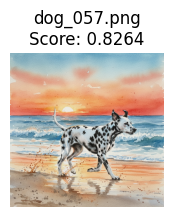

Filename: dog_055.png, Score: 0.7946, Metadata: breed:dalmatian, style:photo, setting:forest, activity:running, mood:happy, color:black, white, green, brown, description:A happy Dalmatian dog is running towards the camera on a dirt path through a lush green forest., embedding:[-0.023165008053183556, 0.0014309872640296817, -0.015011745505034924, -0.03838186711072922, -0.012306811287999153, 0.03561283275485039, -0.010153119452297688, -0.020908759906888008, -0.01689622551202774, -0.023664971813559532, -0.017742319032549858, 0.03268996626138687, 0.005717539228498936, -0.007287939544767141, 0.016485998407006264, 0.01953706331551075, 0.022690683603286743, -0.004595824517309666, 0.014165651984512806, -0.0074610039591789246, -0.03407448157668114, 0.01957552134990692, -0.0016112627927213907, -0.02165229618549347, 0.010806918144226074, 0.0021857409738004208, 0.0329207181930542, -0.00228829775005579, 0.016344983130693436, -0.01601167395710945, 0.0036439697723835707, -0.022293275222182274, -0.0086

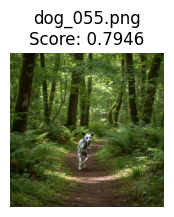

Filename: dog_054.png, Score: 0.7861, Metadata: breed:dalmatian, style:photo, setting:garden, activity:running with a toy, mood:happy, color:white, black, green, red, description:A happy Dalmatian dog is playfully running across a lush green garden, carrying a red spiky toy in its mouth., embedding:[-0.023001208901405334, -0.008280434645712376, -0.018064048141241074, -0.03703518584370613, -0.012381777167320251, 0.04312564432621002, -0.0019275660160928965, -0.007891681976616383, -0.019152555614709854, -0.027860619127750397, -0.008455373346805573, 0.029130544513463974, 0.013308304361999035, 0.002594924997538328, 0.015938865020871162, 0.025631768628954887, 0.01889338716864586, -0.003315737470984459, 0.014500480145215988, -0.013748891651630402, -0.031177975237369537, 0.016509035602211952, -0.008701583370566368, -0.009194004349410534, 0.003929642960429192, -0.006631474941968918, 0.03205914795398712, -0.0064241401851177216, 0.011474687606096268, -0.014293145388364792, 0.0017299500759691, -0.

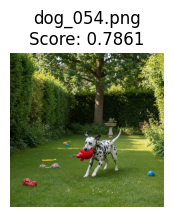

Filename: dog_051.png, Score: 0.7849, Metadata: breed:dalmatian, style:photo, setting:grassy field under a blue sky, activity:walking, mood:alert, color:white, black, green, blue, description:A white and black spotted Dalmatian dog walks attentively across a vast green field under a clear blue sky., embedding:[-0.015662215650081635, -0.003533706534653902, -0.00815470702946186, -0.04105830565094948, -0.008426531217992306, 0.03984156996011734, -0.01088588684797287, -0.01664595864713192, -0.01612819917500019, -0.029693489894270897, -0.01937713846564293, 0.026638710871338844, 0.009552656672894955, -0.0005861195968464017, 0.013772394508123398, 0.023156778886914253, 0.01786269247531891, -0.007656364236027002, 0.009442633017897606, 0.005650047212839127, -0.03155742213129997, 0.018807603046298027, -0.006229290273040533, -0.013655899092555046, 0.006164570339024067, 0.0024917160626500845, 0.030496016144752502, -0.007785803638398647, 0.006899141240864992, -0.020593872293829918, 0.0067632296122610

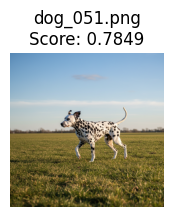

Filename: dog_059.png, Score: 0.7829, Metadata: breed:dalmatian, style:cartoon, setting:city street, activity:running alongside a fire truck, mood:happy, color:white, black, red, blue, grey, orange, green, description:A happy cartoon Dalmatian dog runs on a city street next to a red fire truck., embedding:[-0.0168161541223526, -0.013463319279253483, -0.01298898458480835, -0.04982467740774155, -0.022300247102975845, 0.018583539873361588, -0.00265432707965374, -0.016023429110646248, -0.007719316054135561, -0.0284860972315073, -0.012553635984659195, 0.03092924691736698, 0.027446458116173744, 0.010695281438529491, 2.0990748453186825e-05, 0.016777167096734047, 0.02295002155005932, -0.002157249953597784, 0.01310594379901886, -0.012644603848457336, -0.02929181605577469, 0.007816782221198082, -0.009363244287669659, -0.006556220818310976, 0.005614048335701227, 0.005675776861608028, 0.036205410957336426, -0.011273580603301525, 0.007537379395216703, -0.009031860157847404, 0.004119567573070526, -0

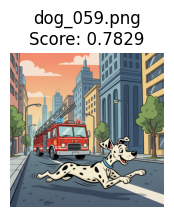

In [ ]:
df_metadata = pd.read_csv('../data/metadata/embeddings.csv')

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

example_queries = [
    # Semantic queries
    ("a happy dog at the beach", None, 5),
    ("a dog sitting in a cafe", None, 5),
    ("a pencil drawing of a dog", None, 5),

    # Filtered queries (only with metadata.csv columns: breed, style, setting, activity, mood, color)
    ("dog", "breed = 'corgi'", 5),
    ("dog", "style = 'cartoon'", 5),
    ("dog", "setting = 'living room'", 5),
    ("dog", "activity = 'eating'", 5),

    # Combined queries (combine semantic + metadata filters from allowed columns)
    ("dog in the snow", "breed = 'husky'", 5),
    ("cute dog posing", "style = 'pencil sketch'", 5),
    ("running on the beach", "breed = 'dalmatian'", 5)
]

dog_path = '../data/dogs/'
for idx, (query, filter_str, k) in enumerate(example_queries, 1):
    print(f"\n--- Example Query {idx} ---")
    print("Query:", query)
    if filter_str:
        print("Filter:", filter_str)
    results = query_index(query, filter=filter_str, k=k)
    for i, r in enumerate(results):
        print(
            f"Filename: {r.get('filename', '')}, "
            f"Score: {r.get('score', ''):.4f}, "
            f"Metadata: " + ", ".join(f"{key}:{value}" for key, value in r.items() if key not in ['filename', 'score'])
        )
        filename = r.get("filename")  # assumes it's a path or relative path to the image
        path = dog_path + filename
        if filename and os.path.exists(path):
            img = mpimg.imread(path)
            plt.figure(figsize=(2, 2))
            plt.imshow(img)
            plt.axis('off')
            plt.title(f"{r.get('filename', '')}\nScore: {r.get('score', 0):.4f}")
            plt.show()
        else:
            print(f"(Image {filename} not found)")


## 5. Submission

- [ ] Create a new branch called `homework-6`
- [ ] Commit and push your work (notebook + CSV files in `temp/`)
- [ ] Create a Pull Request
- [ ] Merge the PR to main
- [ ] Submit the `.ipynb` file on Blackboard

**Note:** Commit the notebook and the `temp/` files that your code created.